<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/mpesa_transaction_by_omoke.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WILLIAM

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/mpesa_synthetic.csv')
display(df.head())

,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,UA0IFD0TV,703.90,58586.32,57882.42,29932.92,30636.82,peer,14.0,1.0,Tue,smartphone,Nairobi,0.0
1,UJAHXTHV3,254.44,8088.00,7833.56,22962.44,23216.88,peer,18.0,10.0,Sat,feature,Eldoret,1.0
2,UEF8MDD4V,609.04,56675.00,56065.96,1029.22,1638.26,till,7.0,5.0,Thu,smartphone,Kisumu,0.0
3,UBT3W5UZB,5255.34,75090.36,69835.02,38.94,5294.28,paybill,11.0,2.0,Mon,smartphone,Nakuru,0.0
4,UGKWNNHJ7,7282.67,24408.96,17126.29,26237.82,33520.49,till,0.0,7.0,Sat,smartphone,Nairobi,0.0


In [ ]:
print("Shape of the dataset:")
print(df.shape)

Shape of the dataset:
(84268, 13)


In [ ]:
print("\nInformation about the dataset:")
df.info()


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84268 entries, 0 to 84267
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           84268 non-null  object 
 1   amount                   84268 non-null  float64
 2   sender_balance_before    84267 non-null  float64
 3   sender_balance_after     84267 non-null  float64
 4   receiver_balance_before  84267 non-null  float64
 5   receiver_balance_after   84267 non-null  float64
 6   transaction_type         84267 non-null  object 
 7   hour                     84267 non-null  float64
 8   month_2026               84267 non-null  float64
 9   day_of_week              84267 non-null  object 
 10  device_type              84267 non-null  object 
 11  region                   84267 non-null  object 
 12  is_fraud                 84267 non-null  float64
dtypes: float64(8), object(5)
memory usage: 8.4+ 

In [ ]:
print("\nDescriptive statistics of the dataset:")
display(df.describe())


Descriptive statistics of the dataset:


,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,hour,month_2026,is_fraud
count,84268.000000,84267.000000,84267.000000,84267.000000,84267.000000,84267.000000,84267.000000,84267.000000
mean,1507.306522,40090.569309,38608.695464,24970.245123,26477.565961,11.455706,6.486917,0.029229
std,1516.266935,23064.412927,23069.569318,14439.951177,14520.105237,6.915052,3.445998,0.168447
min,0.020000,100.180000,0.000000,0.280000,29.390000,0.000000,1.000000,0.000000
25%,431.430000,20032.875000,18543.655000,12470.965000,13952.850000,5.000000,3.000000,0.000000
50%,1036.735000,40239.000000,38696.410000,25006.420000,26518.760000,11.000000,6.000000,0.000000
75%,2083.110000,60026.595000,58547.570000,37469.565000,38973.710000,17.000000,9.000000,0.000000
max,15226.960000,79998.740000,79941.970000,49999.600000,60309.530000,23.000000,12.000000,1.000000


In [ ]:
print("\nNumber of null values per column:")
display(df.isnull().sum())


Number of null values per column:


,0
transaction_id,0
amount,0
sender_balance_before,1
sender_balance_after,1
receiver_balance_before,1
receiver_balance_after,1
transaction_type,1
hour,1
month_2026,1
day_of_week,1


In [ ]:
print("\nRows with null values:")
display(df[df.isnull().any(axis=1)])


Rows with null values:


,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
84267,UAFOLMSNH,301.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Dropping rows with null values...")
df.dropna(inplace=True)

Dropping rows with null values...


In [ ]:
print("\nNew shape of the dataset after dropping null values:")
print(df.shape)


New shape of the dataset after dropping null values:
(84267, 13)


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Drop transaction_id
if 'transaction_id' in df.columns:
    df.drop(columns=['transaction_id'], inplace=True)

# 2. Represent hour in correct format (integer)
if 'hour' in df.columns:
    df['hour'] = df['hour'].astype(int)

# 3. Encode categorical columns
# Check if encoding is already done to avoid errors on re-run
if 'transaction_type' in df.columns:
    categorical_cols = ['transaction_type', 'day_of_week', 'device_type', 'region']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Scale numerical columns (excluding hour and month_2026) to range [0, 1]
scale_cols = [
    'amount', 'sender_balance_before', 'sender_balance_after',
    'receiver_balance_before', 'receiver_balance_after'
]

# Use MinMaxScaler for [0, 1] range
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Display the processed dataframe
print("Data processing complete with Min-Max Scaling (0 to 1):")
display(df.head())

Data processing complete with Min-Max Scaling (0 to 1):


,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,hour,month_2026,is_fraud,transaction_type_peer,transaction_type_till,...,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,device_type_smartphone,region_Kisumu,region_Mombasa,region_Nairobi,region_Nakuru
0,0.046226,0.732005,0.724055,0.598661,0.507753,14,1.0,0.0,True,False,...,False,False,False,True,False,True,False,False,True,False
1,0.016709,0.099975,0.097991,0.459249,0.384662,18,10.0,1.0,True,False,...,True,False,False,False,False,False,False,False,False,False
2,0.039996,0.708083,0.701333,0.020579,0.026690,7,5.0,0.0,False,True,...,False,False,True,False,False,True,True,False,False,False
3,0.345133,0.938567,0.873571,0.000773,0.087340,11,2.0,0.0,False,False,...,False,False,False,False,False,True,False,False,False,True
4,0.478274,0.304246,0.214234,0.524758,0.555591,0,7.0,0.0,False,True,...,True,False,False,False,False,True,False,False,True,False


### Dimensionality Reduction using PCA
We will reduce the 21 columns to a smaller set of principal components while retaining significant variance.

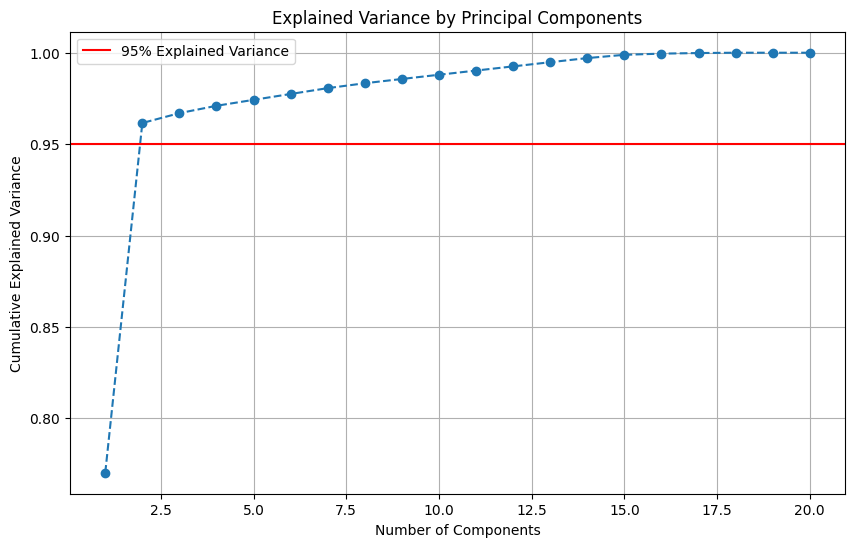

Number of components explaining 95% variance: 2


,PC1,PC2,is_fraud
0,2.539643,-5.489627,0.0
1,6.546957,3.507193,1.0
2,-4.456947,-1.481781,0.0
3,-0.459255,-4.487228,0.0
4,-11.455828,0.523031,0.0


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Prepare features (X) and target (y)
# We drop 'is_fraud' as it is the target label
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Initialize PCA.
# We'll initially look at all components to see the explained variance ratio.
pca = PCA()
X_pca_full = pca.fit_transform(X)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.show()

# Select number of components that explain 95% of the variance
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components explaining 95% variance: {n_components}")

# Apply PCA with the selected number of components
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(X)

# Create a DataFrame with the reduced features
reduced_df = pd.DataFrame(
    data=X_reduced,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
reduced_df['is_fraud'] = y.values # Add target back

display(reduced_df.head())

In [ ]:
# Define target and features clearly
target_column = 'is_fraud'
y = df[target_column]
X = df.drop(columns=[target_column])

print(f"Target column set to: {target_column}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

X
Target column set to: is_fraud
Feature matrix shape: (84267, 20)
Target vector shape: (84267,)


### Exploratory Data Analysis: Summary Statistics & Visualizations
We will examine the distribution of the target variable and key features to identify patterns.

/tmp/ipykernel_32063/84989103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='viridis')


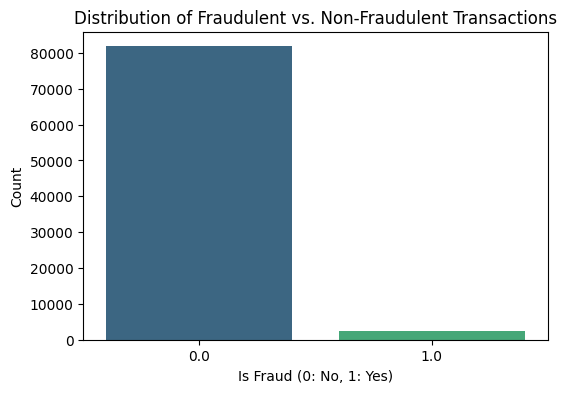

Class Distribution:
is_fraud
0.0    97.077148
1.0     2.922852
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

fraud_counts = df['is_fraud'].value_counts(normalize=True) * 100
print(f"Class Distribution:\n{fraud_counts}")

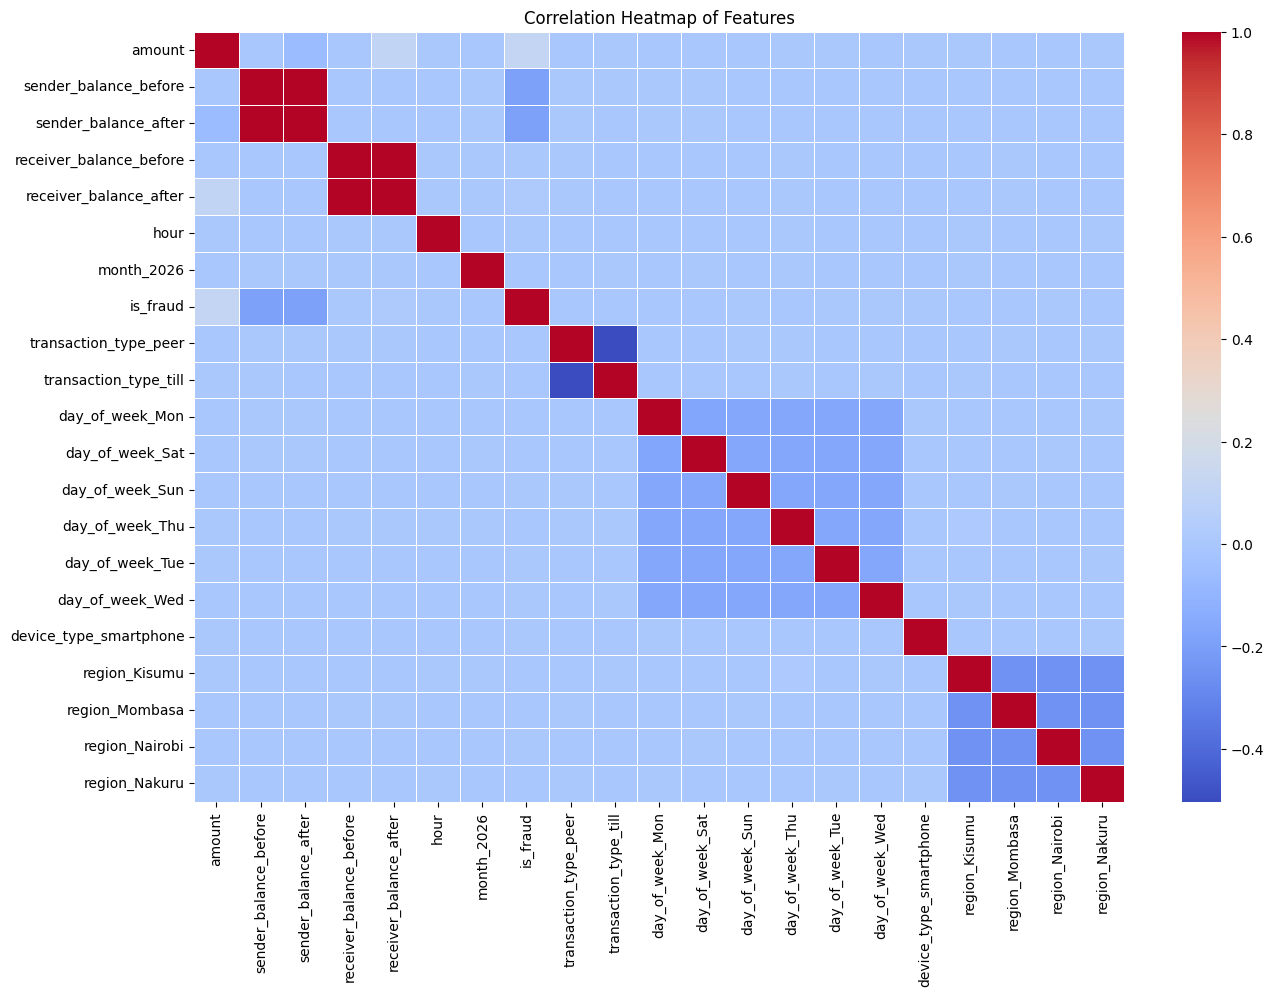

In [ ]:
# 2. Correlation Heatmap
plt.figure(figsize=(15, 10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

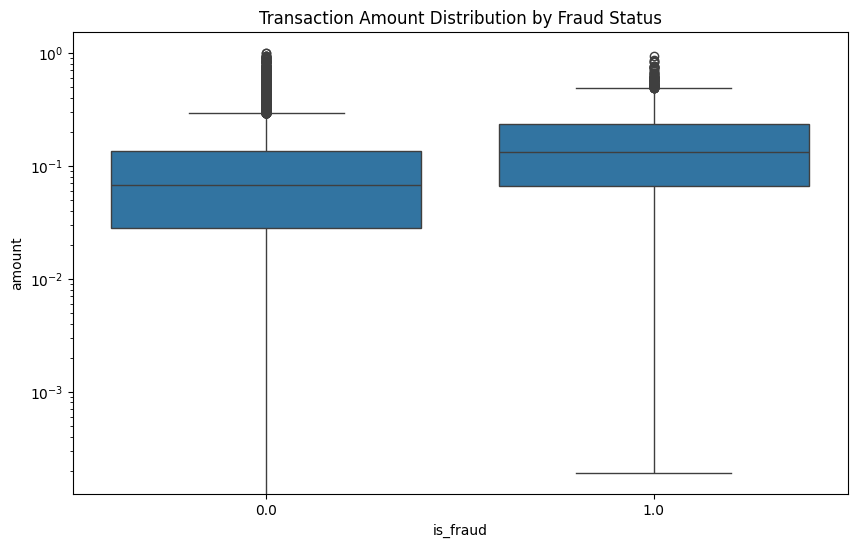

In [ ]:
# 3. Transaction Amount Distribution by Class
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.yscale('log') # Using log scale due to potential outliers
plt.show()

### Machine Learning: Model Training and Evaluation
We will split the data into training and testing sets, then train a Random Forest Classifier to detect fraudulent transactions.

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     16361
         1.0       0.98      0.65      0.79       493

    accuracy                           0.99     16854
   macro avg       0.99      0.83      0.89     16854
weighted avg       0.99      0.99      0.99     16854



<Figure size 800x600 with 0 Axes>

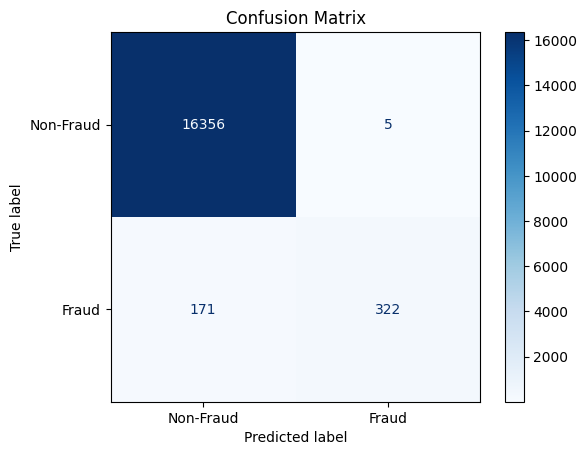

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
# Using class_weight='balanced' to handle the target imbalance
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Training the Random Forest model...

Model Performance:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     16361
         1.0       0.98      0.65      0.79       493

    accuracy                           0.99     16854
   macro avg       0.99      0.83      0.89     16854
weighted avg       0.99      0.99      0.99     16854



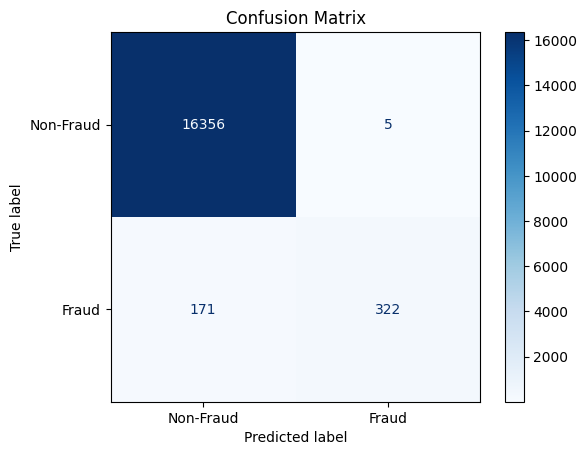

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Split the data into 80% training and 20% testing sets
# We use 'stratify' to ensure the fraud ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest Classifier
# class_weight='balanced' helps the model learn from the infrequent fraud cases
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
print("Training the Random Forest model...")
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
print("\nModel Performance:")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Non-Fraud', 'Fraud'], cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### Logistic Regression Model
We will now train a Logistic Regression model to compare its performance against the Random Forest Classifier.

Training the Logistic Regression model...

Logistic Regression Performance:
              precision    recall  f1-score   support

         0.0       0.99      0.74      0.84     16361
         1.0       0.08      0.77      0.15       493

    accuracy                           0.74     16854
   macro avg       0.54      0.75      0.50     16854
weighted avg       0.96      0.74      0.82     16854



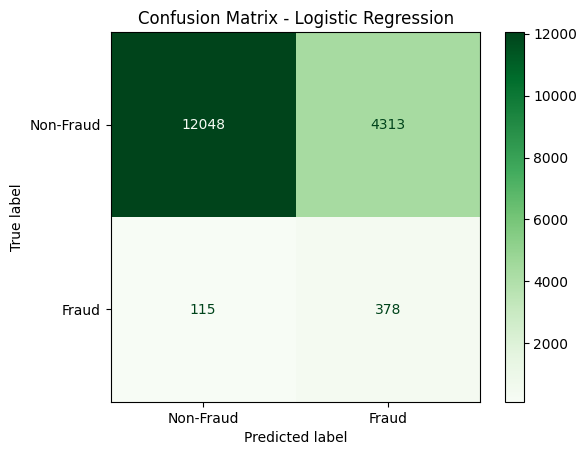

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression
# Using class_weight='balanced' to handle the fraud imbalance
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

print("Training the Logistic Regression model...")
lr_model.fit(X_train, y_train)

# Evaluate the model
y_pred_lr = lr_model.predict(X_test)
print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Non-Fraud', 'Fraud'], cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Decision Tree Model
We will now train a Decision Tree Classifier to see how a single tree performs compared to the ensemble and linear methods.

Training the Decision Tree model...

Decision Tree Performance:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     16361
         1.0       0.63      0.66      0.64       493

    accuracy                           0.98     16854
   macro avg       0.81      0.82      0.82     16854
weighted avg       0.98      0.98      0.98     16854



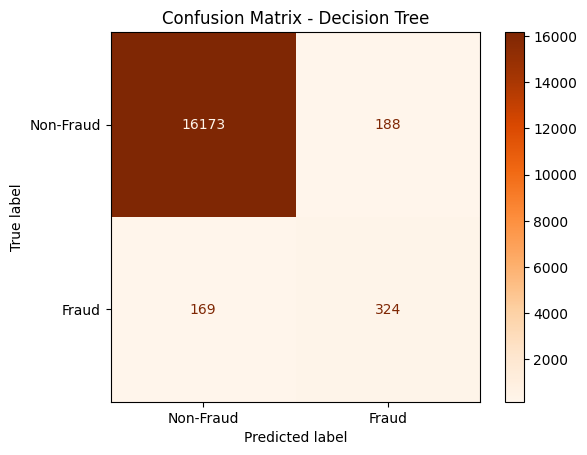

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier
# We continue using class_weight='balanced' for the imbalanced dataset
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

print("Training the Decision Tree model...")
dt_model.fit(X_train, y_train)

# Evaluate the model
y_pred_dt = dt_model.predict(X_test)
print("\nDecision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['Non-Fraud', 'Fraud'], cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### Visualizing the Decision Tree (Pruned)
To make the logic interpretable, we visualize a pruned version of the tree with a maximum depth of 3.

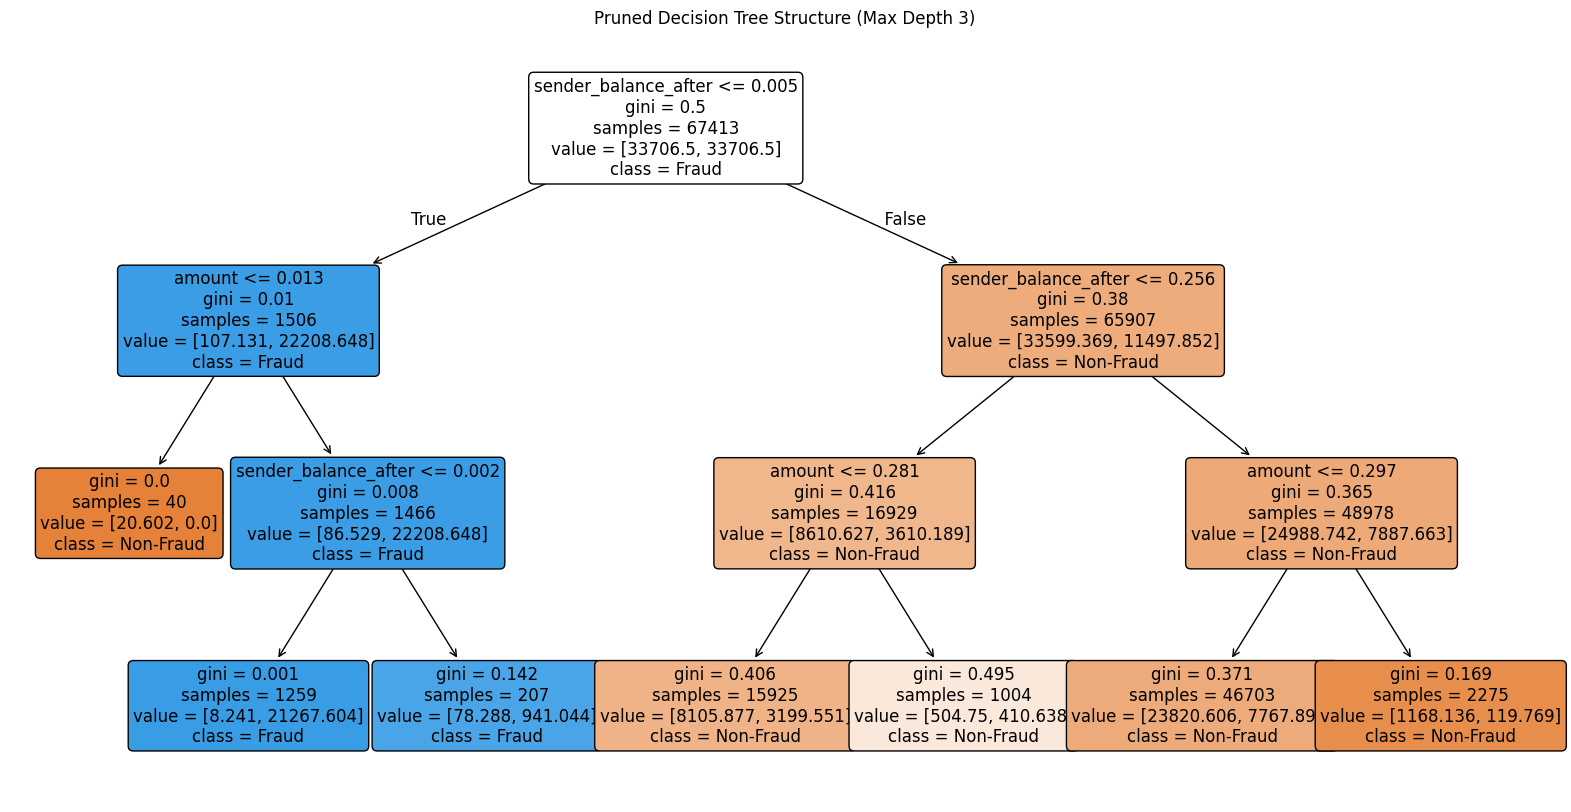

In [ ]:
from sklearn.tree import plot_tree

# Train a small tree for visualization purposes (max_depth=3)
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
pruned_tree.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    pruned_tree,
    feature_names=X.columns.tolist(),
    class_names=['Non-Fraud', 'Fraud'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Pruned Decision Tree Structure (Max Depth 3)")
plt.show()

### XGBoost Model
We will now train an XGBoost classifier, which is a state-of-the-art gradient boosting algorithm, and evaluate its performance.

Training the XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:52:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Performance:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     16361
         1.0       0.85      0.66      0.74       493

    accuracy                           0.99     16854
   macro avg       0.92      0.83      0.87     16854
weighted avg       0.99      0.99      0.99     16854



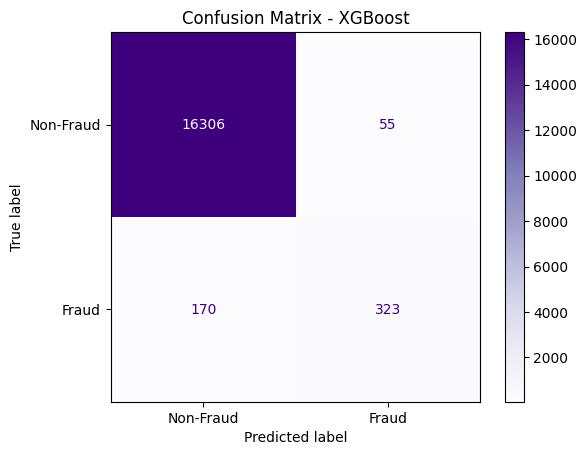

In [ ]:
import xgboost as xgb

# Calculate scale_pos_weight for imbalanced data
# count(negative) / count(positive)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize and train the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Training the XGBoost model...")
xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred_xgb = xgb_model.predict(X_test)
print("\nXGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['Non-Fraud', 'Fraud'], cmap='Purples')
plt.title('Confusion Matrix - XGBoost')
plt.show()

### Hyperparameter Tuning with GridSearchCV
We will now perform a grid search to find the optimal parameters for the XGBoost model. We focus on improving the F1-score for the minority class.

Starting Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Best F1 Score: 0.7604022927389184

Optimized XGBoost Performance:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     16361
         1.0       0.91      0.66      0.76       493

    accuracy                           0.99     16854
   macro avg       0.95      0.83      0.88     16854
weighted avg       0.99      0.99      0.99     16854



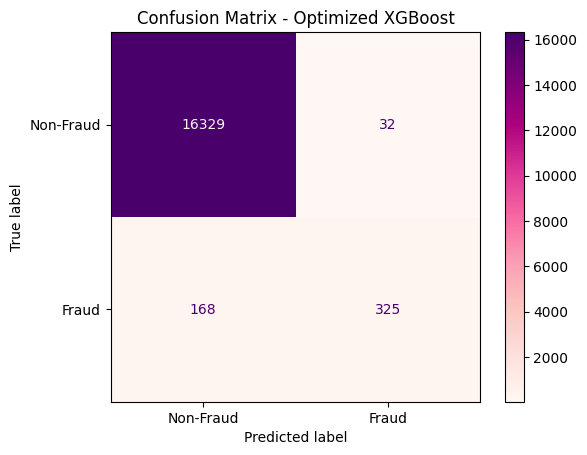

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Initialize the classifier
xgb_tuning = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

# Initialize GridSearchCV
# We use 'f1' or 'recall' as the scoring metric to prioritize catching fraud
grid_search = GridSearchCV(
    estimator=xgb_tuning,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_}")

# Evaluate the best model on the test set
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("\nOptimized XGBoost Performance:")
print(classification_report(y_test, y_pred_best))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=['Non-Fraud', 'Fraud'], cmap='RdPu')
plt.title('Confusion Matrix - Optimized XGBoost')
plt.show()

### Hyperparameter Tuning with RandomizedSearchCV (Random Forest)
We will use `RandomizedSearchCV` to explore a wider range of hyperparameters for the Random Forest model to see if we can improve the recall for the fraud class.

Starting Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best F1 Score: 0.7872055480751131

Optimized Random Forest Performance:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     16361
         1.0       0.97      0.65      0.78       493

    accuracy                           0.99     16854
   macro avg       0.98      0.83      0.89     16854
weighted avg       0.99      0.99      0.99     16854



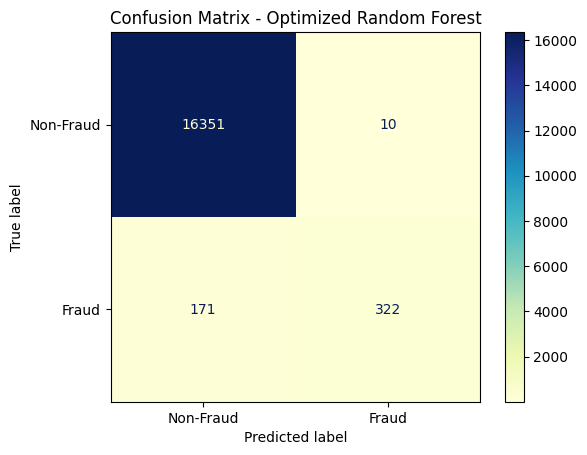

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define the parameter distributions
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize the Random Forest Classifier
rf_tuning = RandomForestClassifier(random_state=42, class_weight='balanced')

# Initialize RandomizedSearchCV
# We'll run 10 iterations and use 3-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best F1 Score: {random_search.best_score_}")

# Evaluate the best model on the test set
best_rf = random_search.best_estimator_
y_pred_rf_best = best_rf.predict(X_test)

print("\nOptimized Random Forest Performance:")
print(classification_report(y_test, y_pred_rf_best))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_best, display_labels=['Non-Fraud', 'Fraud'], cmap='YlGnBu')
plt.title('Confusion Matrix - Optimized Random Forest')
plt.show()

### Performance Matrix: Tuning Method Comparison

We compare the results of `GridSearchCV` (applied to XGBoost) and `RandomizedSearchCV` (applied to Random Forest).

In [ ]:
import pandas as pd

# Data from previous cell executions
performance_data = {
    'Model': ['XGBoost', 'Random Forest'],
    'Tuning Method': ['GridSearchCV', 'RandomizedSearchCV'],
    'Best Parameters': [
        "learning_rate: 0.01, max_depth: 5, n_estimators: 200",
        "n_estimators: 100, max_depth: 20, max_features: 'log2'"
    ],
    'Best CV F1-Score': [0.7604, 0.7872],
    'Test Precision (Fraud)': [0.91, 0.97],
    'Test Recall (Fraud)': [0.66, 0.65],
    'Test F1-Score (Fraud)': [0.76, 0.78]
}

performance_matrix = pd.DataFrame(performance_data)
display(performance_matrix)

,Model,Tuning Method,Best Parameters,Best CV F1-Score,Test Precision (Fraud),Test Recall (Fraud),Test F1-Score (Fraud)
0,XGBoost,GridSearchCV,"learning_rate: 0.01, max_depth: 5, n_estimator...",0.7604,0.91,0.66,0.76
1,Random Forest,RandomizedSearchCV,"n_estimators: 100, max_depth: 20, max_features...",0.7872,0.97,0.65,0.78


### Feature Importance Comparison
We will compare the top features identified by the optimized Random Forest and XGBoost models to understand their decision-making process.

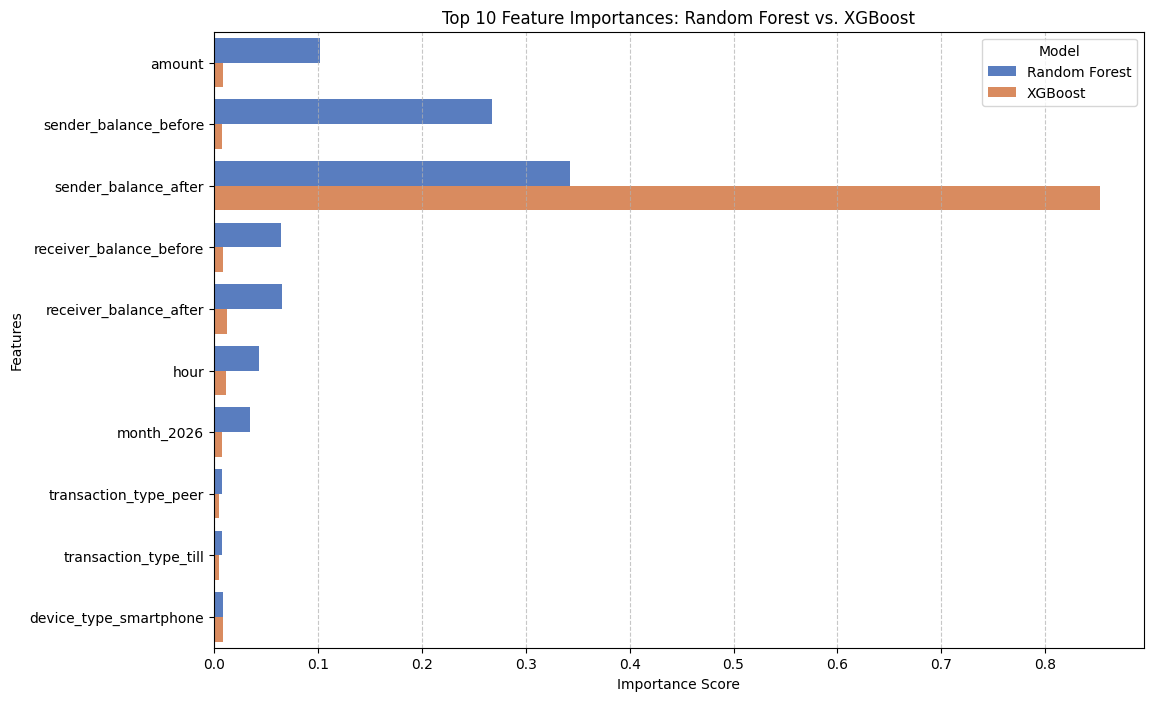

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Extract feature importances
rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_,
    'Model': 'Random Forest'
})

xgb_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_,
    'Model': 'XGBoost'
})

# Combine and sort
combined_importance = pd.concat([rf_importances, xgb_importances])
# Get top 10 features based on RF for cleaner visualization
top_features = rf_importances.sort_values(by='Importance', ascending=False).head(10)['Feature']
filtered_importance = combined_importance[combined_importance['Feature'].isin(top_features)]

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Model', data=filtered_importance, palette='muted')
plt.title('Top 10 Feature Importances: Random Forest vs. XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Addressing Class Imbalance with SMOTE
We will use `SMOTE` to oversample the minority (fraud) class in our training data. This helps the model learn more robust features for the infrequent class.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data only
# It's crucial NOT to apply SMOTE to the test set to maintain a realistic evaluation
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training class distribution: {Counter(y_train)}")
print(f"Resampled training class distribution: {Counter(y_train_resampled)}")

Original training class distribution: Counter({0.0: 65443, 1.0: 1970})
Resampled training class distribution: Counter({0.0: 65443, 1.0: 65443})


### Re-training Random Forest with SMOTE Data
Now we re-train our best-performing model (Random Forest) on the balanced dataset.

Performance after SMOTE:
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98     16361
         1.0       0.39      0.67      0.49       493

    accuracy                           0.96     16854
   macro avg       0.69      0.82      0.73     16854
weighted avg       0.97      0.96      0.96     16854



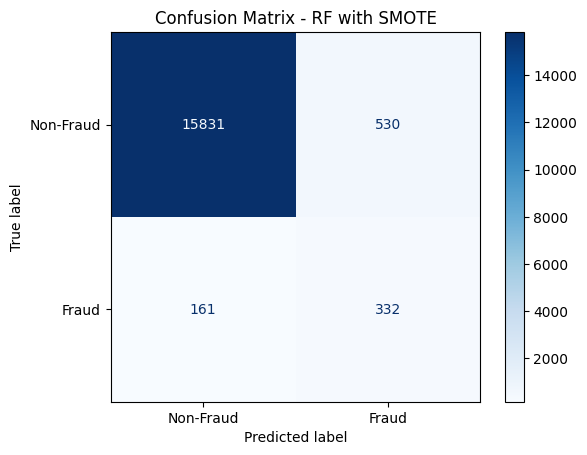

In [ ]:
# Initialize Random Forest with optimized parameters from earlier
smote_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    random_state=42
)

smote_rf.fit(X_train_resampled, y_train_resampled)

# Evaluate
y_pred_smote = smote_rf.predict(X_test)
print("Performance after SMOTE:")
print(classification_report(y_test, y_pred_smote))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, display_labels=['Non-Fraud', 'Fraud'], cmap='Blues')
plt.title('Confusion Matrix - RF with SMOTE')
plt.show()

### Regression Analysis: Predicting Transaction Amount
To calculate regression metrics like RMSE, MAE, and R², we will pivot from classification to predicting the continuous variable `amount`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Prepare data for regression
# Target: amount, Features: everything except amount and is_fraud
X_reg = df.drop(columns=['amount', 'is_fraud'])
y_reg = df['amount']

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Regression Feature shape: {X_reg.shape}")

Regression Feature shape: (84267, 19)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_regression(model, X_test, y_test, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"--- {name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}\n")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# 1. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
rf_metrics = evaluate_regression(rf_reg, X_test_reg, y_test_reg, "Random Forest Regressor")

# 2. XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_reg.fit(X_train_reg, y_train_reg)
xgb_metrics = evaluate_regression(xgb_reg, X_test_reg, y_test_reg, "XGBoost Regressor")

--- Random Forest Regressor Metrics ---
RMSE: 0.0769
MAE:  0.0533
R²:   0.3787

--- XGBoost Regressor Metrics ---
RMSE: 0.0184
MAE:  0.0133
R²:   0.9646



In [ ]:
import pandas as pd

regression_results = pd.DataFrame([rf_metrics, xgb_metrics])
print("Regression Performance Summary:")
display(regression_results)

Regression Performance Summary:


,Model,RMSE,MAE,R2
0,Random Forest Regressor,0.076890,0.053317,0.378657
1,XGBoost Regressor,0.018354,0.013253,0.964596


### Model Comparison: ROC Curves
We will now plot the Receiver Operating Characteristic (ROC) curve for each classification model and calculate the Area Under the Curve (AUC) to compare their diagnostic abilities.

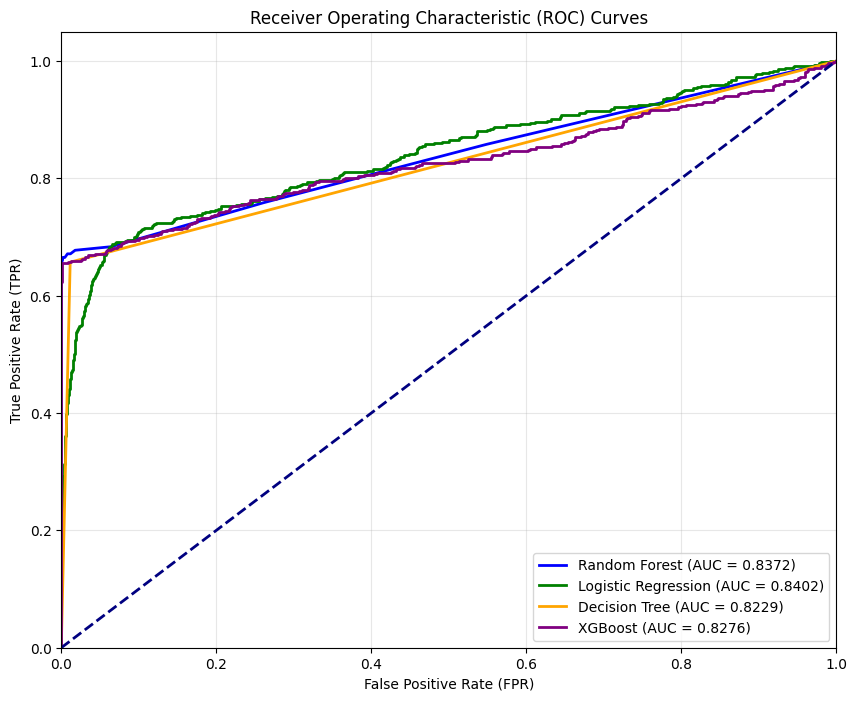

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prepare to plot
plt.figure(figsize=(10, 8))

# List of models and their names for the loop
models = [
    (rf_model, 'Random Forest', 'blue'),
    (lr_model, 'Logistic Regression', 'green'),
    (dt_model, 'Decision Tree', 'orange'),
    (xgb_model, 'XGBoost', 'purple')
]

for model_obj, name, color in models:
    # Get predicted probabilities for the positive class
    if hasattr(model_obj, 'predict_proba'):
        y_probs = model_obj.predict_proba(X_test)[:, 1]
    else:
        # Some models might not have predict_proba in specific versions, though these do
        y_probs = model_obj.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Plot the random chance line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Confusion Matrix Heatmaps Comparison
We will visualize the confusion matrices for all models side-by-side to compare their ability to correctly identify fraud vs. non-fraud transactions.

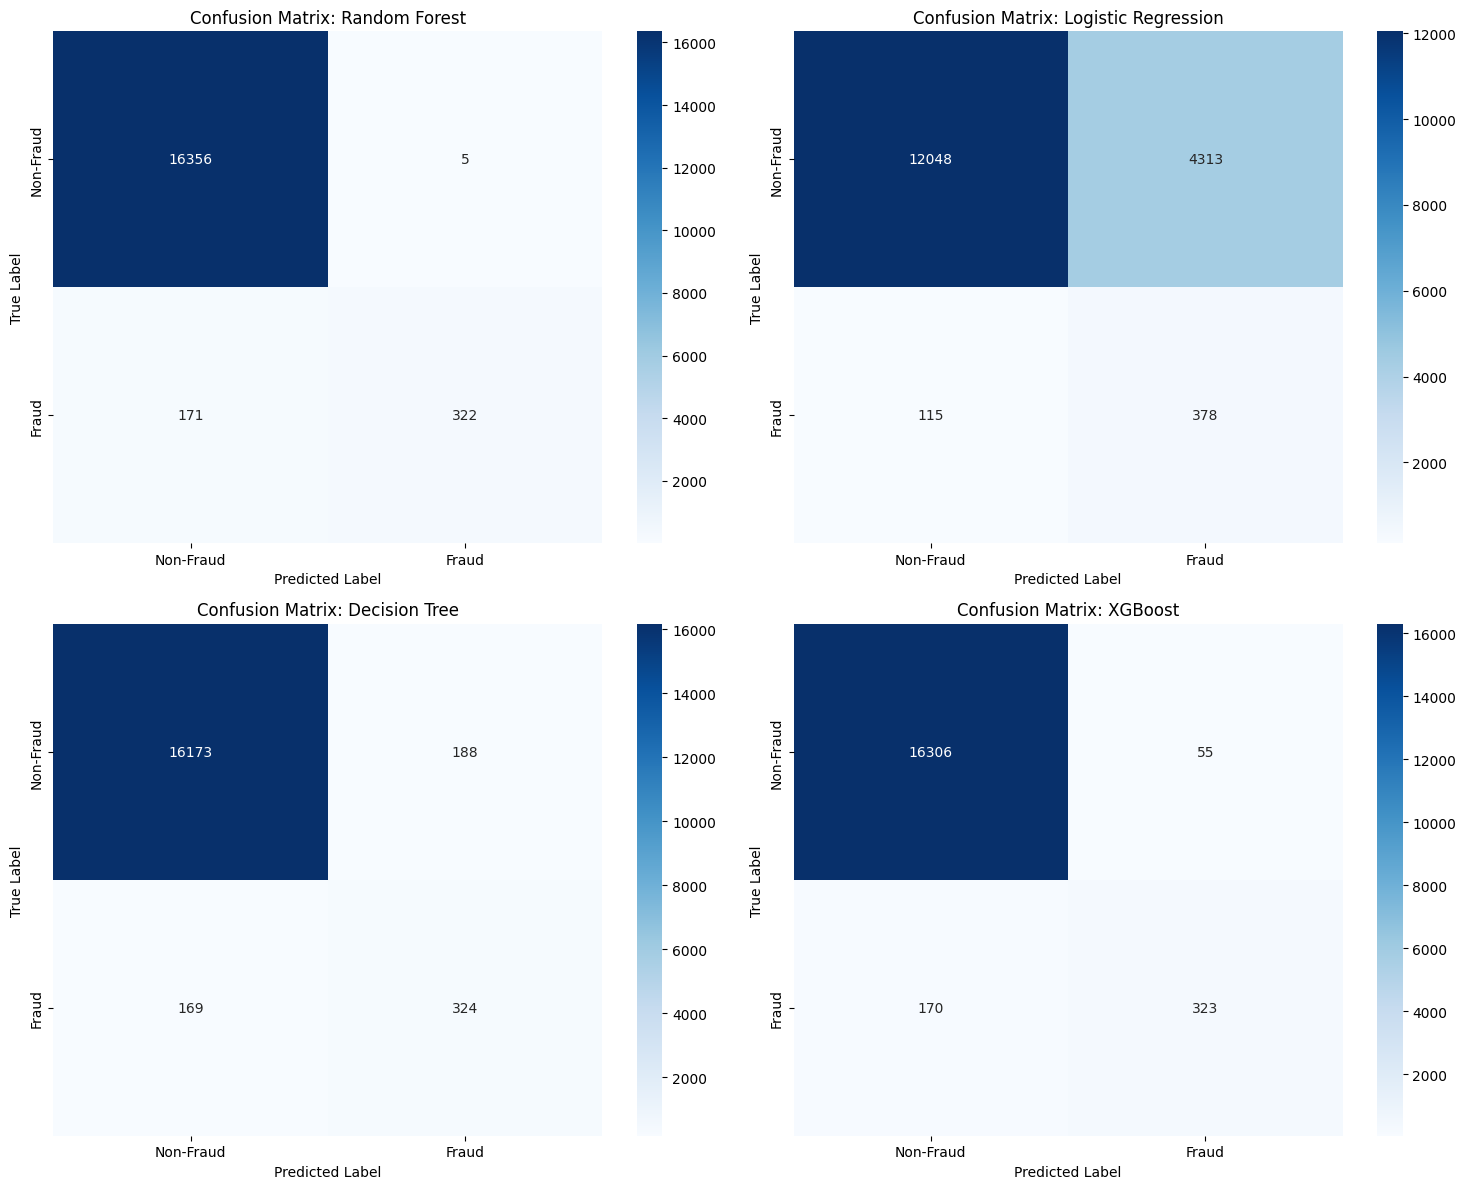

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Define the models and their predictions
# We use the predictions generated from earlier cells
model_preds = [
    ('Random Forest', y_pred),
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('XGBoost', y_pred_xgb)
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, pred) in enumerate(model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()